# Market Risk Project

In [793]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


<div style="border-left: 3px solid rgba(0,0,0,0.25); padding: 8px 10px; margin: 12px 0;">
<strong style="color:steelblue">Note:</strong>
<span style="color:steelblue">
Blue text is used to highlight key interpretations and methodological choices.
</span>
</div>

<div style="border-left: 3px solid rgba(0,0,0,0.25); padding: 8px 10px; margin: 12px 0;">
<strong style="color:firebrick">Note:</strong>
<span style="color:firebrick">
Red text indicates explicit references to the course material.
</span>
</div>


***Disclaimer.*** : A complementary written report is also available. It adopts a more narrative approach and provides a clearer, more direct overview of the analysis and conclusions.

***Attention.*** : Please ensure that the entire project folder is opened when running this notebook. Otherwise, figures may not display correctly and the code may fail to execute due to missing datasets.

***GitHub Repository.***: The complete project, including this notebook and all associated files, is available at:  https://github.com/AlexisAHG


## Question A - Non-parametric Value-at-Risk

In this section, we estimate a one-day Value-at-Risk (VaR) for Natixis stock returns.
We deliberately rely on a non-parametric approach, which allows us to avoid strong distributional assumptions. We keep the implementation simple and close to the lecture.




### Data and returns

We use daily closing prices of Natixis stock, since this frequency is standard for short-term risk measurement.
We compute simple daily returns as relative price variations, consistently with the definition used in the course.



In [794]:
data = pd.read_csv("data/NatixisStock.csv", sep=";")

data["Date"] = pd.to_datetime(data["Date"], dayfirst=True)
data["Price"] = data["Price"].str.replace(",", ".").astype(float)

data = data.sort_values("Date")


In [795]:
data["Return"] = data["Price"].pct_change()
data = data.dropna()

We split the sample into two distinct periods.
The first one (2015–2016) is used to estimate the risk measures, while the second one (2017–2018) is kept for validation.
<span style="color:steelblue">This separation allows us to evaluate the out-of-sample performance of the VaR estimate.
</span>


In [796]:
data_2015_2016 = data[
    (data["Date"] >= "2015-01-01") & (data["Date"] <= "2016-12-31")
]

data_2017_2018 = data[
    (data["Date"] >= "2017-01-01") & (data["Date"] <= "2018-12-31")
]

### A.a Non-parametric Value-at-Risk estimation (2015–2016)

In this section, we estimate the one-day Value-at-Risk using a non-parametric approach based on Kernel Density Estimation (KDE). 
This method allows us to capture the empirical shape of the return distribution without imposing a parametric assumption.

#### Kernel choice

In practice, the estimation relies on a kernel density approach.
Following the instructions of TD1, we use a biweight kernel to estimate the return distribution.
We chose this kernel because it provides a smooth density estimate while remaining compactly supported,
which helps limit the influence of extreme observations.



In [797]:
def biweight_kernel(u):
    return (15/16) * (1 - u**2)**2 * (abs(u) <= 1)


In [798]:
# We focus on the returns observed over the estimation period (2015–2016)
returns = data_2015_2016["Return"].values
n = len(returns)

# Bandwidth selection using a rule-of-thumb formula
h = 1.06 * np.std(returns) * n ** (-1/5)

def kde_biweight(x, data, h):
    u = (x - data) / h
    return np.sum(biweight_kernel(u)) / (len(data) * h)


#### Kernel density estimation

Using the biweight kernel defined above, we estimate the density of returns 
over the 2015–2016 period.  


<span style="color:steelblue">
For the bandwidth, we stick to a simple rule-of-thumb. It’s not perfect, but it gives us a reasonable smoothing level without turning this part into an optimisation exercise.
</span>


#### Visual inspection of the estimated density

Before computing the Value-at-Risk, we visually inspect the estimated return distribution.
This step allows us to check whether the density exhibits asymmetry or heavy tails,
which are key features when dealing with risk measures based on extreme losses.


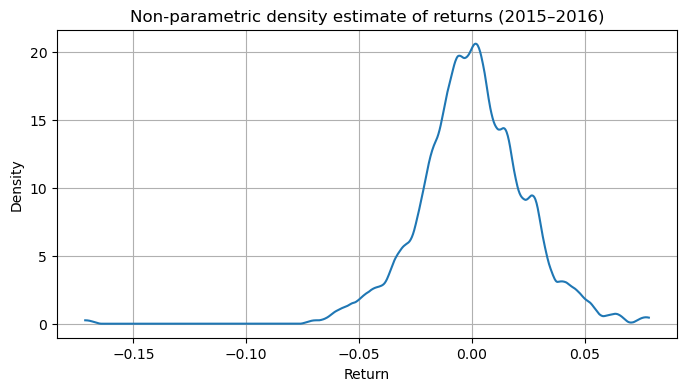

In [799]:
# Before computing the VaR, we plot the estimated density to visually check 
# the shape of the return distribution, especially the left tail.
x_grid = np.linspace(returns.min(), returns.max(), 1000)

kde_vals = np.array([kde_biweight(x, returns, h) for x in x_grid])

plt.figure(figsize=(8, 4))
plt.plot(x_grid, kde_vals)
plt.title("Non-parametric density estimate of returns (2015–2016)")
plt.xlabel("Return")
plt.ylabel("Density")
plt.grid(True)

plt.savefig("kde_density.png", dpi=300, bbox_inches="tight")
plt.show()


<span style="color:steelblue">This graphical inspection is not required for the computation itself, but it allows us to visually assess
whether the estimated distribution behaves reasonably, especially in the left tail which is crucial for risk measurement. We mainly use it to sanity-check the left tail.
</span>


#### Computation of the non-parametric Value-at-Risk

Once the return distribution has been estimated, we compute the Value-at-Risk (VaR) as a quantile of this distribution.
In a non-parametric framework, the VaR corresponds to the lower tail quantile of the return distribution.


<div style="border-left: 4px solid firebrick; padding: 10px; margin: 15px 0;">

<span style="color:firebrick; display:block; margin-bottom:8px;">
<strong>Reference to the course material</strong>
</span>

<span style="color:firebrick">
The theoretical definition used in this section directly follows the formulation introduced in the lecture notes.
For clarity and traceability, we include below the corresponding slide from the course (page 68).
</span>

</div>


<img src="course/1.jpeg"
     style="width:60%; display:block; margin:20px auto;">


At this stage, we compute the VaR as a tail quantile of the distribution estimated with our kernel approach.
Concretely, we build an estimated CDF by numerically integrating the KDE on a fine grid, <span style="color:steelblue"> which stays simple
and also makes the link with the course definition (VaR = quantile) very explicit.
</span>


In [800]:
# Risk level (easy to change)
alpha = 0.05  # 5% left-tail level

# We approximate the CDF implied by the KDE by numerical integration on the grid.
# This is a simple way to extract the alpha-quantile from the non-parametric distribution.

dx = x_grid[1] - x_grid[0]

# Normalize the KDE to make sure it integrates to ~1 on the grid (numerical stability)
kde_area = np.trapezoid(kde_vals, x_grid)
kde_pdf = kde_vals / kde_area

kde_cdf = np.cumsum(kde_pdf) * dx
kde_cdf = np.clip(kde_cdf, 0, 1)  # just to avoid tiny numerical overshoots

# VaR threshold = alpha-quantile of the KDE-based distribution
VaR_nonparametric = np.interp(alpha, kde_cdf, x_grid)

print(f"Non-parametric (KDE-based) VaR threshold : {VaR_nonparametric:.6f}")


Non-parametric (KDE-based) VaR threshold : -0.038011


The estimated one-day Value-at-Risk at the 5% level corresponds to a moderate loss located in the left tail
of the return distribution, which is consistent with what we observe on the estimated density.



#### Graphical summary of the non-parametric VaR

We provide a graphical summary of the non-parametric approach by displaying:
- the estimated KDE with the VaR threshold,
- the empirical and KDE-based cumulative distribution functions,
highlighting the position of the Value-at-Risk within the left tail.


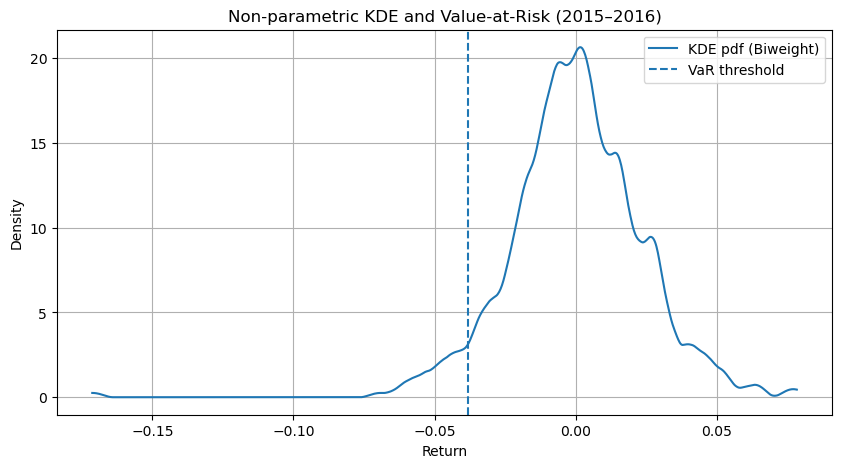

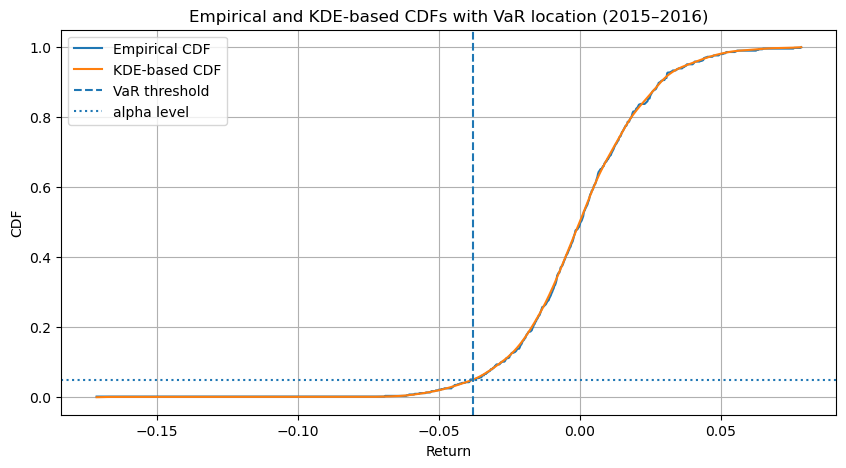

In [801]:
# Empirical CDF on the same grid (useful comparison with KDE-based CDF)
ecdf_vals = np.array([np.mean(returns <= x) for x in x_grid])

plt.figure(figsize=(10, 5))
plt.plot(x_grid, kde_pdf, label="KDE pdf (Biweight)")
plt.axvline(VaR_nonparametric, linestyle="--", label="VaR threshold")
plt.title("Non-parametric KDE and Value-at-Risk (2015–2016)")
plt.xlabel("Return")
plt.ylabel("Density")
plt.grid(True)
plt.legend()

plt.savefig("kde_var.png", dpi=300, bbox_inches="tight")
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(x_grid, ecdf_vals, label="Empirical CDF")
plt.plot(x_grid, kde_cdf, label="KDE-based CDF")
plt.axvline(VaR_nonparametric, linestyle="--", label="VaR threshold")
plt.axhline(alpha, linestyle=":", label="alpha level")
plt.title("Empirical and KDE-based CDFs with VaR location (2015–2016)")
plt.xlabel("Return")
plt.ylabel("CDF")
plt.grid(True)
plt.legend()

plt.savefig("cdf_var.png", dpi=300, bbox_inches="tight")
plt.show()



Overall, this non-parametric approach allows us to estimate the Value-at-Risk
without relying on strong distributional assumptions.
By focusing on the empirical behavior of returns and on the left tail of the distribution,
we obtain a risk measure that is directly driven by the observed data.

<strong>Conclusion (A.1):</strong> Using the 2015–2016 returns, we obtain a non-parametric estimate of the one-day Value-at-Risk
based on the KDE of the return distribution. The position of the VaR in the left tail is consistent with the shape
of the estimated density and with what we observe on the empirical distribution.
<span style="color:steelblue">
This gives us a reasonable in-sample benchmark, which we can now confront with future observations in an out-of-sample setting.
</span>

### A.b Out-of-sample validation (2017–2018)

In this subsection, we assess the out-of-sample performance of the non-parametric Value-at-Risk.
Using returns from 2017–2018, we compute the violation rate and compare it to the theoretical level α.


In [802]:
# Question A-b: out-of-sample check (2017–2018)
returns_out = data_2017_2018["Return"].values

violations = returns_out < VaR_nonparametric
n_obs = len(returns_out)
n_viol = int(np.sum(violations))
viol_rate = n_viol / n_obs

print("Out-of-sample backtest (2017–2018)")
print(f"Observations: {n_obs}")
print(f"Violations (return < VaR): {n_viol}")
print(f"Observed violation rate: {100*viol_rate:.2f}%")
print(f"Theoretical level (alpha): {100*alpha:.2f}%")


Out-of-sample backtest (2017–2018)
Observations: 510
Violations (return < VaR): 8
Observed violation rate: 1.57%
Theoretical level (alpha): 5.00%


<strong>Conclusion (A.2).</strong> Over the 2017–2018 period, the observed violation rate (1.57%) is clearly below the theoretical level (alpha = 5%). This suggests that the non-parametric VaR is conservative on this out-of-sample window.
<span style="color:steelblue">
We think this mainly comes from the smoothing effect introduced by the KDE. Since the model is calibrated on the 2015–2016 period, this smoothing results in a safety margin that remains visible out-of-sample.
</span>


<strong>
This concludes Question A, which combines an in-sample non-parametric estimation of the Value-at-Risk (2015–2016)
and an out-of-sample validation over the 2017–2018 period.
</strong>

<span style="color:steelblue">
<strong>
One limitation we keep in mind is that the VaR level still depends on the bandwidth choice,
which directly controls the amount of smoothing in the tails.
</strong>
</span>


## Question B - Expected Shortfall

In this question, we compute the Expected Shortfall associated with the non-parametric VaR estimated in Question A.
The goal is to quantify the average loss in the worst cases, beyond the VaR threshold.


<div style="border-left: 4px solid firebrick; padding: 10px; margin: 15px 0;">

<span style="color:firebrick; display:block; margin-bottom:8px;">
<strong>Reference to the course material</strong>
</span>

<span style="color:firebrick">
According to the course, the Expected Shortfall at level \( \alpha \) is defined as the
conditional expectation of losses, given that the loss exceeds the VaR at the same level (page 75)
</span>

</div>


<img src="course/2.jpeg"
     style="width:60%; display:block; margin:20px auto;">


We compute the Expected Shortfall using the same non-parametric framework as in Question A.
Concretely, we focus on the returns that fall below the VaR threshold and compute their average loss.
This ensures full consistency between the VaR and the Expected Shortfall.


In [803]:
# Expected Shortfall computation (non-parametric, consistent with Question A)

# We work on the same in-sample period as for the VaR (2015–2016)
returns_in = data_2015_2016["Return"].values

# Losses are defined as negative returns
losses_in = -returns_in

# VaR threshold at level alpha (already computed in Question A)
VaR_level = -VaR_nonparametric  # convert back to losses

# Expected Shortfall: average loss beyond the VaR threshold
ES_nonparametric = losses_in[losses_in >= VaR_level].mean()

print(f"Non-parametric Expected Shortfall at 95% confidence level: {ES_nonparametric:.6f}")
print(f"Non-Parametric VaR (Biweight Kernel) at 95% confidence level: {VaR_level:.6f}")


Non-parametric Expected Shortfall at 95% confidence level: 0.053362
Non-Parametric VaR (Biweight Kernel) at 95% confidence level: 0.038011


<strong>
Conclusion: the Expected Shortfall is significantly higher than the corresponding VaR
(around 5.3% versus 3.8%), which confirms that extreme losses tend to be more severe
than what the VaR threshold alone suggests.
</strong>


## Question C - EVT (Pickands estimator) and EVT-based VaR

In this question, we adopt an Extreme Value Theory (EVT) approach to analyse the tail
behaviour of Natixis daily returns.


EVT is basically a tail approach: instead of modelling the full return distribution, we focus on the extreme observations.

In practice, we study the two tails separately:
- the right tail (large positive returns),
- the left tail (large negative returns).

To handle the left tail cleanly, we work with loss magnitudes \(L = -R\) (so losses are positive numbers).  
This way, “more extreme loss” simply means “larger \(L\)”, which fits the standard EVT notation.


<div style="border-left: 4px solid firebrick; padding: 10px; margin: 15px 0;">

  <span style="color:firebrick; display:block; margin-bottom:8px;">
    <strong>Reference to the course material</strong>
  </span>

  <span style="color:firebrick">
    Pickands estimator (slide 180) and EVT-based VaR (slide 187)
  </span>

</div>


<img src="course/3.jpeg"
     style="width:65%; display:block; margin:20px auto;">


<img src="course/4.jpeg"
     style="width:60%; display:block; margin:20px auto;">


We include below the Pickands estimator formula and the EVT-based Value-at-Risk definition, exactly as introduced in the course.  
These expressions are the starting point for what we implement in the next cells.

We now move to the empirical part. We use the daily return series previously built for Natixis, and we split it into gains and losses to study the two tails separately.


### C.a Pickands tail index (right tail vs left tail)

We first estimate the tail index \(\xi\) using the Pickands estimator, on both tails (gains vs losses).  
Since the estimate depends on how many extreme observations we keep, we test a few standard choices of \(k(n)\).


In [804]:
# Natixis dataset
nat = pd.read_csv("data/NatixisStock.csv", sep=";")

# Small cleaning (European commas)
nat["Price"] = pd.to_numeric(nat["Price"].astype(str).str.replace(",", "."), errors="coerce")

# IMPORTANT: dates are dd/mm/yyyy in the csv
nat["Date"] = pd.to_datetime(nat["Date"], dayfirst=True, errors="coerce")

nat = nat.dropna(subset=["Date", "Price"]).sort_values("Date").reset_index(drop=True)

# Returns
nat["Return"] = nat["Price"].pct_change()
nat = nat.dropna(subset=["Return"]).reset_index(drop=True)

print("n_returns =", len(nat))
print("date range:", nat["Date"].min(), "->", nat["Date"].max())


n_returns = 1022
date range: 2015-01-05 00:00:00 -> 2018-12-31 00:00:00


In [805]:
# Build gain/loss samples from Natixis returns
R_nat = nat["Return"].dropna().astype(float).values

G_nat = np.sort(R_nat[R_nat > 0])        # gains strictly positive
L_nat = np.sort(-R_nat[R_nat < 0])       # losses as strictly positive magnitudes

print(f"Sample sizes -> gains: {len(G_nat)}, losses: {len(L_nat)}")


Sample sizes -> gains: 498, losses: 519


<div style="border-left: 4px solid firebrick; padding: 10px; margin: 15px 0;">
<span style="color:firebrick"><strong>Reference to the course material</strong></span>

<br><br>
<span style="color:firebrick">
In EVT, the sign of the tail index $\xi$ gives a standard qualitative classification:
$\xi>0$ (Fréchet, heavy tails), $\xi=0$ (Gumbel), $\xi<0$ (Weibull).
We only use this to interpret the sign of our Pickands estimates. ((see EVT lectures, same section, page 166)
</span>
</div>


<img src="course/5.jpeg"
     style="width:60%; display:block; margin:20px auto;">


In [806]:
def pickands_xi(x_sorted, k):
    # x_sorted must be sorted (ascending) and contain positive tail magnitudes
    n = len(x_sorted)
    if 4 * k >= n:
        return np.nan

    x1 = x_sorted[n - k]
    x2 = x_sorted[n - 2 * k]
    x3 = x_sorted[n - 4 * k]

    num = x1 - x2
    den = x2 - x3

    #If gaps collapse, Pickands is not usable for this k
    if (num <= 0) or (den <= 0):
        return np.nan

    return np.log(num / den) / np.log(2)


def k_choice(n, mode="sqrt"):
    if mode == "sqrt":
        k = int(round(np.sqrt(n)))
    elif mode == "log":
        k = int(round(np.log(n)))
    elif mode == "n_over_log":
        k = int(round(n / np.log(n)))
    else:
        raise ValueError("mode must be 'sqrt', 'log', or 'n_over_log'")

    # Keep 4k < n so Pickands is defined
    k = min(k, (n - 1) // 4)
    return max(k, 1)


for mode in ["sqrt", "log", "n_over_log"]:
    kG = k_choice(len(G_nat), mode)
    kL = k_choice(len(L_nat), mode)

    xiG = pickands_xi(G_nat, kG)
    xiL = pickands_xi(L_nat, kL)

    print(f"\nPickands tail index (xi), k(n) = {mode}")
    print(f"  Gains  : k = {kG}, xi = {xiG}")
    print(f"  Losses : k = {kL}, xi = {xiL}")





Pickands tail index (xi), k(n) = sqrt
  Gains  : k = 22, xi = 0.7195506129331686
  Losses : k = 23, xi = 0.39064816105019273

Pickands tail index (xi), k(n) = log
  Gains  : k = 6, xi = 0.5772338569463368
  Losses : k = 6, xi = -0.5089715779341932

Pickands tail index (xi), k(n) = n_over_log
  Gains  : k = 80, xi = -0.20197084544428853
  Losses : k = 83, xi = 0.0729484088621743


<span style="color:steelblue">
With our reference choice $k(n)=\sqrt{n}$, we get $\hat{\xi}\approx 0.72$ for gains and $\hat{\xi}\approx 0.39$ for losses.
Using the course interpretation, both tails look heavy ($\xi>0$), and the gain tail appears heavier than the loss tail.

That said, the estimate is sensitive to the choice of $k(n)$ (the sign can even change), so we keep this as a qualitative conclusion and use other $k(n)$ values only as a robustness check.
</span>


<strong>Conclusion (C.a):</strong>
With Pickands and our reference choice $k(n)=\sqrt{n}$, we obtain positive tail indices on both sides: $\hat{\xi}\approx 0.72$ for gains and $\hat{\xi}\approx 0.39$ for losses. Using the course interpretation, this points to heavy tails on both sides, with gains looking heavier on this baseline.  
However, the stability plot and the alternative $k(n)$ choices show that $\hat{\xi}$ is quite sensitive to $k$ in our finite sample. We therefore keep a cautious interpretation and treat the other $k(n)$ values as robustness checks rather than picking a single “final” $\xi$.


### C.b EVT-based Value-at-Risk (Pickands, course slide 187)

Here we apply the EVT-based VaR formula given in the course (slide 187), still working on loss magnitudes $L=-R$.

One small practical point: the formula uses order statistics $X_{n-k+1:n}$ and $X_{n-2k+1:n}$.
In our code, we store losses in an ascending sorted array `L`, so:
- $X_{n-k+1:n}$ corresponds to `L[n-k]` (the k-th largest loss),
- $X_{n-2k+1:n}$ corresponds to `L[n-2*k]`.



<span style="color:steelblue">
One small practical check: with the threshold $u=X_{n-k}$, EVT extrapolation is meant for tail levels such that $1-p < k/n$ (i.e. $p > 1-k/n$).  
Here, with $n=519$ and $k=23$, we get $p > 1-23/519 \approx 0.956$, so we focus on $p\ge 0.975$.
</span>


In [807]:
def VaR_EVT_Pickands(x_sorted, k, xi, p):
    n = len(x_sorted)
    if (k <= 0) or (2*k >= n) or np.isnan(xi):
        return np.nan

    X_nk = x_sorted[n - k]          # X_{n-k+1:n}
    X_n2k = x_sorted[n - 2*k]       # X_{n-2k+1:n}

    a = k / (n * (1 - p))

    if abs(xi) < 1e-8:
        coef = np.log(a) / np.log(2)
    else:
        coef = (a**xi - 1) / (1 - 2**(-xi))

    return coef * (X_nk - X_n2k) + X_nk


# use the loss sample built from Natixis returns
loss_tail = L_nat

k_ref = int(round(np.sqrt(len(loss_tail))))
k_ref = min(k_ref, (len(loss_tail) - 1) // 4)

xi_L = pickands_xi(loss_tail, k_ref)

print(f"n_losses = {len(loss_tail)}")
print(f"k_ref = {k_ref}")
print(f"xi^P (loss tail) = {xi_L}")

p_list = [0.975, 0.99, 0.995, 0.999]

print("\nEVT VaR (Pickands)")
for p in p_list:
    var_loss = VaR_EVT_Pickands(loss_tail, k_ref, xi_L, p)
    var_return = -var_loss
    print(f"p={p:.3f} (tail={1-p:.3f}) -> VaR ≈ {var_return:.2%}")




n_losses = 519
k_ref = 23
xi^P (loss tail) = 0.39064816105019273

EVT VaR (Pickands)
p=0.975 (tail=0.025) -> VaR ≈ -5.76%
p=0.990 (tail=0.010) -> VaR ≈ -8.51%
p=0.995 (tail=0.005) -> VaR ≈ -11.36%
p=0.999 (tail=0.001) -> VaR ≈ -21.85%


<span style="color:steelblue">
With $k(n)=\sqrt{n}$ on the loss sample ($n=519$), we obtain $\hat{\xi}^P \approx 0.39$, so the loss tail looks heavy ($\xi>0$).  
Using the course formula (slide 187), the EVT-based VaR becomes more extreme as $p$ increases:
<br><br>
$p=0.975$ → about -5.76%, $p=0.99$ → -8.51%, $p=0.995$ → -11.36%, and $p=0.999$ → -21.85%.  
So moving from 99% to 99.9% makes a big difference, which is exactly the point of EVT (rarer events, much larger losses).
<br><br>
We still keep the usual caution in mind: this extrapolation depends on the choice of $k$ and on the stability of Pickands, and we only have about 500 observations in the loss tail.
</span>


<h4 style="margin-top:10px;">(Optional) Pickands stability check</h4> As a quick robustness check, we plot $\hat{\xi}$ as a function of $k$.  
This is not required, but it helps to see whether Pickands is stable for a reasonable range of extremes.  
If there is a flat zone, it means the estimate is relatively robust; if not, we just keep a cautious interpretation.
</span>


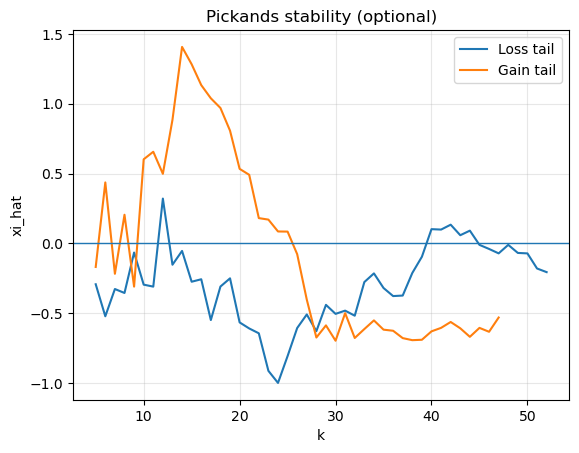

In [808]:
def xi_curve(x_sorted, k_min=5, k_max=120):
    n = len(x_sorted)
    k_max = min(k_max, (n-1)//4)
    ks = np.arange(k_min, k_max+1)
    xis = np.array([pickands_xi(x_sorted, int(k)) for k in ks], dtype=float)
    return ks, xis

ksL, xiL_curve = xi_curve(L, k_min=5, k_max=120)
ksG, xiG_curve = xi_curve(G, k_min=5, k_max=120)

plt.figure()
plt.plot(ksL, xiL_curve, label="Loss tail")
plt.plot(ksG, xiG_curve, label="Gain tail")
plt.axhline(0, linewidth=1)
plt.xlabel("k")
plt.ylabel("xi_hat")
plt.title("Pickands stability (optional)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<span style="color:steelblue">
Very quickly: on the loss tail, $\hat{\xi}$ stays mostly above 0 for a reasonable mid-range of $k$ (roughly $k\approx 20$ to $80$), so heavy losses look plausible, even if there is no perfect plateau.  
On the gain tail, the curve is much more unstable, so the gain-side $\hat{\xi}$ should be taken more cautiously.  
Overall, the plot mainly confirms one thing: Pickands is sensitive in finite samples, so we rely on robustness checks rather than one “final” number.
</span>


<strong>Conclusion (C.b):</strong>
Applying the EVT-based VaR formula from the course (slide 187) on loss magnitudes $L=-R$, we obtain increasingly extreme VaR levels as $p$ approaches 1 (e.g., around -8.51% at 99% and around -21.85% at 99.9%). This is exactly what EVT is meant to capture: deeper tail quantiles become much larger than what empirical quantiles can reliably provide with a limited sample. At the same time, this extrapolation depends on the choice of $k$ and on the stability of $\hat{\xi}$, so the EVT-VaR results should be interpreted with caution and backed by the stability check.


<strong>Conclusion:</strong><br>
<strong>In this question, we used EVT in the course framework: we estimated tail indices with Pickands and then computed an EVT-based VaR on the loss tail.  
For our reference choice $k(n)=\sqrt{n}$, the loss tail index is positive ($\hat{\xi}^P \approx 0.39$), which supports a heavy-tail view, and the EVT-based VaR becomes much more extreme at very high confidence levels (e.g., 99.9%).  
At the same time, the stability plot confirms that Pickands can be sensitive to $k$ in finite samples, so we interpret these results with caution and use robustness checks rather than a single “final” number.
</strong>


## Question D – Price impact (Bouchaud's model)

In this question, we estimate the parameters of Bouchaud’s price impact model and we comment on whether the specification is reasonable for the TD4 dataset.


We proceed as follows:
- we recall the model introduced in the course,
- we adopt a simplified (but model-consistent) specification to make estimation feasible on TD4,
- we estimate the parameters and comment on the goodness of fit and on the model specification.


### Bouchaud's price impact model

We recall the price impact model introduced in the course: prices move because of the cumulative contribution of past trades.

<div style="border-left: 4px solid firebrick; padding: 10px; margin: 15px 0;">

<span style="color:firebrick"><strong>Reference to the course material</strong></span>

<span style="color:firebrick">
This section follows the formulation given in the lecture notes (slide 133). The screenshot below is included for traceability.
</span>

<br><br>
<span style="color:firebrick">
Main variables: trade sign $\varepsilon_t \in \{-1,+1\}$, spread $S_t$, traded volume $V_t$, concavity exponent $r$, and impact kernel $G(\cdot)$.
</span>

<br><br>
<span style="color:steelblue">
In practice, the TD4 dataset has many missing volumes, so we will estimate a simplified version on the subset where required variables are available (and we will state clearly what this changes in the interpretation).
</span>

</div>


<img src="course/6.jpeg"
     style="width:60%; display:block; margin:20px auto;">


### From the course model to an estimable specification

<div style="border-left: 4px solid firebrick; padding: 10px; margin: 15px 0;">

<span style="color:firebrick"><strong>Reference to the course material</strong></span>

<span style="color:firebrick">
Starting from the transitory impact model (slide 133), we move to a trade-level specification by working with one-step price changes:
$$
\Delta p_t = p_t - p_{t-1}.
$$
</span>

<br><br>
<span style="color:firebrick">
Since the course model has infinite memory, we approximate it with a finite window of length $L$ (only the last $L$ trades enter the impact term).
For the decay, we use a decreasing power-law kernel, consistent with the course discussion (see also the illustration in slide 136).
In slide 136, the scaling factor is denoted $V$; here we use $\kappa$ for the same role. The slide also mentions $\lambda$ for volatility weighting in the liquidity-spiral setting, but we do not estimate $\lambda$ in this question:
$$
G(\ell)=\frac{1}{\ell^{\gamma}}, \qquad \ell \ge 1.
$$
</span>

<br><br>
<span style="color:steelblue">
Empirically, we estimate $(\kappa,r,\gamma)$ under this parametric specification.
Because volume is missing for most trades in TD4, we use a practical convention later on to avoid collapsing the sample (stated explicitly when defining the regressor).
</span>

</div>


<img src="course/7.jpeg"
     style="width:60%; display:block; margin:20px auto;">


### Data preparation and variable alignment

We load the TD4 dataset and standardize the main columns (names + numeric formats).  
At this stage, we only clean the data; filtering (missing volumes, lag window $L$) will be done later.


In [809]:
td4 = pd.read_csv("data/Dataset TD4.csv", sep=";")

td4 = td4.rename(columns={
    "transaction date (1=1day=24 hours)": "time",
    "bid-ask spread": "spread",
    "volume of the transaction (if known)": "volume",
    "Sign of the transaction": "sign",
    "Price (before transaction)": "price"
})

for col in ["time", "spread", "volume", "sign", "price"]:
    td4[col] = pd.to_numeric(td4[col].astype(str).str.replace(",", "."), errors="coerce")

td4.head()

,time,spread,volume,sign,price
0,0.000202,0.1100,8.0,-1,100.000
1,0.001070,0.1030,NaN,1,99.984
2,0.001496,0.1015,NaN,-1,100.029
3,0.003336,0.0920,NaN,1,99.979
4,0.003952,0.1106,NaN,1,100.060


The column `price` is a pre-trade price level, so we work with one-step changes:
$$
\Delta p_t = p_t - p_{t-1}.
$$

Since $\Delta p_t$ compares trade $t$ to trade $t-1$, we align it with the information available at the previous trade, i.e. $(\varepsilon_{t-1}, S_{t-1}, V_{t-1})$.

At this stage we do not filter yet: we just build the full aligned table, and we will apply the availability conditions (missing volume, lag window $L$) later.


In [810]:
# Small but important step: we sort by time before taking differences
td4 = td4.sort_values("time").reset_index(drop=True)

# I extract the raw series (names are the cleaned ones from the previous cell)
p = td4["price"].to_numpy()
S = td4["spread"].to_numpy()
V = td4["volume"].to_numpy()
eps = td4["sign"].to_numpy()

# One-step price changes: dp[i] = p[i+1] - p[i]
# (so dp is aligned with the previous trade i)
dp = np.diff(p)

# Align predictors with the previous trade (same length as dp)
work = pd.DataFrame({
    "time_prev": td4["time"].to_numpy()[:-1],
    "dp": dp,
    "S_prev": S[:-1],
    "V_prev": V[:-1],
    "eps_prev": eps[:-1],
})

# Very basic checks (just to see what we have before filtering)
n_trades = len(td4)
n_dp = len(work)

miss_V = td4["volume"].isna().sum()
miss_S = td4["spread"].isna().sum()

print(f"Total trades (raw): {n_trades}")
print(f"One-step Δp observations: {n_dp}")
print(f"Missing volume in raw data: {miss_V} ({miss_V/n_trades:.1%})")
print(f"Missing spread  in raw data: {miss_S} ({miss_S/n_trades:.1%})")

# How many observations already have the basic variables available?
valid_basic = work[["dp", "S_prev", "V_prev", "eps_prev"]].notna().all(axis=1)
print(f"Obs with (Δp, eps_prev, S_prev, V_prev) available: {valid_basic.sum()} / {n_dp}")

# Quick check: on average, dp should be positive after eps_prev=+1 and negative after eps_prev=-1
tmp = work[["dp", "eps_prev"]].dropna()
m = tmp.groupby("eps_prev")["dp"].mean()
print(f"Mean Δp | eps_prev = +1: {m.get(1, np.nan)}")
print(f"Mean Δp | eps_prev = -1: {m.get(-1, np.nan)}")

work.head()


Total trades (raw): 1001
One-step Δp observations: 1000
Missing volume in raw data: 864 (86.3%)
Missing spread  in raw data: 0 (0.0%)
Obs with (Δp, eps_prev, S_prev, V_prev) available: 137 / 1000
Mean Δp | eps_prev = +1: 0.06333667334669339
Mean Δp | eps_prev = -1: -0.06119161676646709


,time_prev,dp,S_prev,V_prev,eps_prev
0,0.000202,-0.016,0.1100,8.0,-1
1,0.001070,0.045,0.1030,NaN,1
2,0.001496,-0.050,0.1015,NaN,-1
3,0.003336,0.081,0.0920,NaN,1
4,0.003952,0.100,0.1106,NaN,1


<div style="color:steelblue">
From the diagnostics above, the spread is always observed, but the volume is missing in most trades (about 86%), so only a small fraction of observations has $(\Delta p, \varepsilon_{t-1}, S_{t-1}, V_{t-1})$ fully available (137 out of 1000).

A quick check also shows that the trade sign has the expected direction on average (positive mean $\Delta p$ after $\varepsilon_{t-1}=+1$ and negative after $\varepsilon_{t-1}=-1$).

For this reason, when building the lagged regressor $X_t(r,\gamma)$, we keep the full trade-time sequence and set the contribution of a missing past volume to zero. This is a practical compromise to keep enough observations for the estimation.
</div>


### Construction of the lagged signed-order-flow regressor

From the course transitory impact model (slide 133), short-run price changes depend on past signed trades through a decaying kernel $G(\ell)$.
With a finite memory window $L$ and a power-law decay, we build a lagged regressor:
$$
X_t(r,\gamma)=\sum_{\ell=1}^{L} \ell^{-\gamma}\,\varepsilon_{t-\ell}\,S_{t-\ell}\,V_{t-\ell}^{\,r}.
$$

The estimable relation is then:
$$
\Delta p_t \approx \kappa\,X_t(r,\gamma) + u_t.
$$

Practical point (data issue): volume is missing most of the time (we saw it in the diagnostics), so requiring all lagged volumes to be observed over $\ell=1,\dots,L$ would shrink the sample too much.
We therefore use a simple convention: when a past volume is missing, its contribution to the sum is set to zero. We will keep this limitation in mind when interpreting the estimates.


In [811]:
# Finite memory window: we only use the last L trades in the sum
L1 = 50

# Arrays from the aligned table "work" (built in the previous cell)
dp_arr  = work["dp"].to_numpy()
S_arr   = work["S_prev"].to_numpy()
V_arr   = work["V_prev"].to_numpy()
eps_arr = work["eps_prev"].to_numpy()

def compute_X(eps, S, V, r, gamma, L):

    # kernel weights: 1/ell^gamma for ell = 1..L
    weights = np.arange(1, L + 1, dtype=float) ** (-gamma)

    # volume term: V^r when V is observed and > 0, else 0
    V_term = np.zeros_like(V, dtype=float)
    ok = np.isfinite(V) & (V > 0)
    V_term[ok] = V[ok] ** r

    # signed order-flow part at each trade time (before lagging)
    base = pd.Series(eps * S * V_term)

    # build X by shifting the base series (easy and readable)
    X = np.zeros(len(base), dtype=float)
    for ell in range(1, L + 1):
        X += weights[ell - 1] * base.shift(ell).fillna(0.0).to_numpy()

    return X

# Quick sanity check (just to see that the construction behaves as expected)
X_check = compute_X(eps_arr, S_arr, V_arr, r=0.5, gamma=1.0, L=L1)

usable = np.isfinite(dp_arr) & np.isfinite(X_check) & (np.abs(X_check) > 0)

print("Lag window L:", L1)
print("Usable observations (non-zero X):", usable.sum(), "/", len(dp_arr))
print("Any NaN in X on usable rows:", np.isnan(X_check[usable]).any())
print("Share of missing volumes (V_prev):", np.isnan(V_arr).mean())


Lag window L: 50
Usable observations (non-zero X): 999 / 1000
Any NaN in X on usable rows: False
Share of missing volumes (V_prev): 0.863


<span style="color:steelblue">
Quick check: with $L=50$, we can compute $X_t(r,\gamma)$ for almost all one-step observations (999 out of 1000), and the constructed series has no missing values (by construction, missing past volumes give a zero contribution).

At the same time, volume is missing in about 86% of trades. Under our convention (missing volume $\Rightarrow$ zero contribution), many terms of the sum do not enter $X_t$. We will therefore interpret the estimates of $(\kappa,r,\gamma)$ with caution.
</span>


### Estimation of $(\kappa,r,\gamma)$

For fixed $(r,\gamma)$, the specification
$$
\Delta p_t \approx \kappa\,X_t(r,\gamma) + u_t
$$
is linear in $\kappa$. We estimate $\kappa$ by OLS without intercept (coherent with the model: if $X_t=0$, the conditional mean impact is $0$):
$$
\hat{\kappa}(r,\gamma)=\frac{\sum_t X_t(r,\gamma)\,\Delta p_t}{\sum_t X_t(r,\gamma)^2}.
$$

We then choose $(r,\gamma)$ on a simple grid search by minimizing the mean squared error:
$$
\mathrm{MSE}(r,\gamma)=\frac{1}{n}\sum_t\left(\Delta p_t - \hat{\kappa}(r,\gamma)\,X_t(r,\gamma)\right)^2,
$$
computed on the observations used in the regression.


In [812]:
def estimate_kappa_ols(X, Y):
    # OLS without intercept: kappa = (X'Y)/(X'X)
    denom = np.dot(X, X)
    if denom == 0:
        return np.nan
    return np.dot(X, Y) / denom

def mse(y, y_hat):
    return np.mean((y - y_hat) ** 2)

# Target: one-step price changes
Y = dp_arr

# Simple grids (student choice: coarse first, refine later if needed)
r_grid = np.arange(0.0, 1.01, 0.1)
gamma_grid = np.arange(0.1, 2.01, 0.1)

best = {"mse": np.inf, "kappa": np.nan, "r": np.nan, "gamma": np.nan}

for r in r_grid:
    for gamma in gamma_grid:
        # Build X_t(r,gamma) using the aligned series (eps, spread, volume)
        X = compute_X(eps_arr, S_arr, V_arr, r=r, gamma=gamma, L=L1)

        # Keep only rows where both Y and X are finite and X is not degenerate
        valid = np.isfinite(Y) & np.isfinite(X) & (np.abs(X) > 0)
        Xv, Yv = X[valid], Y[valid]

        if len(Yv) == 0:
            continue

        kappa_hat = estimate_kappa_ols(Xv, Yv)
        if np.isnan(kappa_hat):
            continue

        Y_hat = kappa_hat * Xv
        current_mse = mse(Yv, Y_hat)

        if current_mse < best["mse"]:
            best = {"mse": current_mse, "kappa": kappa_hat, "r": r, "gamma": gamma}
    
best


{'mse': np.float64(0.005425879131224422),
 'kappa': np.float64(-0.047615695904314595),
 'r': np.float64(0.0),
 'gamma': np.float64(2.0)}

### Grid-search result (coarse)

On the coarse grid, we obtain:
- $\hat r = 0.0$, $\hat \gamma = 2.0$, $\hat \kappa \approx -0.0476$ (MSE $\approx 5.43\times 10^{-3}$).

<div style="color:steelblue">
Simple reading:
- $\hat r = 0.0$ suggests that, in this sample, the calibration does not really exploit the concavity in volume (consistent with the fact that volume is missing most of the time).
- $\hat \gamma = 2.0$ is on the boundary of the tested grid, so we interpret it as a rough order of magnitude (the result may be sensitive to the grid choice).
- The negative $\hat \kappa$ indicates that, with our constructed regressor $X_t$, the fitted relation is overall negative on the used sample; given the data limitations, we keep the interpretation cautious.
</div>


<strong>Conclusion:
Overall, our simplified Bouchaud impact calibration is consistent with the course framework, but the estimates should be interpreted cautiously because transaction volumes are missing most of the time in TD4 and the grid search is coarse. </strong>


## Question E - Haar Wavelets

In this question, we analyze FX rates using Haar wavelets and the Hurst exponent.  We study correlations across different time scales and the scaling behavior of volatility.





### Data loading and first inspection

Before starting the analysis, we load the FX dataset:


In [813]:
df_wavelet = pd.read_csv("data/Dataset TD5.csv",sep=";")
print(df_wavelet.head(15))

       GBPEUR Curncy Unnamed: 1 Unnamed: 2  Unnamed: 3     SEKEUR Curncy  \
0               Date       HIGH        LOW         NaN              Date   
1   07/03/2016 09:00     1,2932     1,2917         NaN  07/03/2016 09:00   
2   07/03/2016 09:15      1,294      1,293         NaN  07/03/2016 09:15   
3   07/03/2016 09:30     1,2943     1,2922         NaN  07/03/2016 09:30   
4   07/03/2016 09:45      1,293     1,2913         NaN  07/03/2016 09:45   
5   07/03/2016 10:00     1,2931     1,2921         NaN  07/03/2016 10:00   
6   07/03/2016 10:15     1,2926     1,2921         NaN  07/03/2016 10:15   
7   07/03/2016 10:30      1,293     1,2906         NaN  07/03/2016 10:30   
8   07/03/2016 10:45     1,2917     1,2907         NaN  07/03/2016 10:45   
9   07/03/2016 11:00      1,292     1,2912         NaN  07/03/2016 11:00   
10  07/03/2016 11:15     1,2921     1,2907         NaN  07/03/2016 11:15   
11  07/03/2016 11:30     1,2912     1,2905         NaN  07/03/2016 11:30   
12  07/03/20

As we can see, the dataset is kind of horrible. As we did in the TD, we cleaned the dataset via excel directly, we just put names of the columns
directly instead of "Unnamed: n" and we deleted the columns that are empty, to make it cleaner. After this cleaning step, we load the cleaned dataset below and use it for the rest of the analysis.

Finally, we have :

In [814]:
df_wavelet2 = pd.read_csv("data/Dataset_TD5_clean.csv", sep=";")
print(df_wavelet2.head())

               Date GBPEUR_HIGH GBPEUR_LOW SEKEUR_HIGH SEKEUR_LOW CADEUR_HIGH  \
0  07/03/2016 09:00      1,2932     1,2917     0,10725     0,1072      0,6842   
1  07/03/2016 09:15       1,294      1,293     0,10728    0,10717      0,6849   
2  07/03/2016 09:30      1,2943     1,2922     0,10726    0,10719      0,6844   
3  07/03/2016 09:45       1,293     1,2913     0,10728    0,10721      0,6844   
4  07/03/2016 10:00      1,2931     1,2921     0,10725    0,10719       0,684   

  CADEUR_LOW  
0     0,6829  
1     0,6841  
2     0,6837  
3     0,6839  
4     0,6835  


Now that the dataset is clean and properly loaded, we can start the analysis. We first focus on multiresolution correlations using Haar wavelets.

### E.a - Multiresolution correlations using Haar wavelets

In this part, we look at how the three FX rates move together depending on the time scale. Using Haar wavelets, we compute multiresolution correlations between GBPEUR, SEKEUR and CADEUR and discuss whether an Epps effect appears.

This multiresolution analysis focuses on the scale-dependent cross-correlation structure of FX returns, separating short-term fluctuations from longer-term movements.

<div style="border-left: 4px solid firebrick; padding: 10px; margin: 15px 0;">

<span style="color:firebrick; display:block; margin-bottom:6px;">
<strong>Reference to the course material</strong>
</span>

<span style="color:firebrick">
Haar wavelet and multiresolution analysis (page 291)
</span>

</div>


<img src="course/8.jpeg"
     style="width:60%; display:block; margin:20px auto;">


Based on this multiresolution framework, we now move on to the implementation and apply the Haar wavelet decomposition to the FX return series.

In [815]:
# Some numerical columns are read as strings because of the decimal separator (comma instead of dot).
# We convert them to floats so that we can perform basic numerical operations.
cols = [
    'GBPEUR_HIGH', 'GBPEUR_LOW',
    'SEKEUR_HIGH', 'SEKEUR_LOW',
    'CADEUR_HIGH', 'CADEUR_LOW'
]

for c in cols:
    df_wavelet2[c] = (df_wavelet2[c].astype(str).str.replace(',', '.', regex=False).astype(float) )


In [816]:
# We compute the mid-price as the average between the high and the low prices
df_wavelet2['GBPEUR_avg'] = (df_wavelet2['GBPEUR_HIGH'] + df_wavelet2['GBPEUR_LOW']) / 2
df_wavelet2['SEKEUR_avg'] = (df_wavelet2['SEKEUR_HIGH'] + df_wavelet2['SEKEUR_LOW']) / 2
df_wavelet2['CADEUR_avg'] = (df_wavelet2['CADEUR_HIGH'] + df_wavelet2['CADEUR_LOW']) / 2

In [817]:
# Returns are computed at the finest sampling frequency (15 minutes)
df_wavelet2['GBPEUR_returns'] = df_wavelet2['GBPEUR_avg'].pct_change().dropna()
df_wavelet2['SEKEUR_returns'] = df_wavelet2['SEKEUR_avg'].pct_change().dropna()
df_wavelet2['CADEUR_returns'] = df_wavelet2['CADEUR_avg'].pct_change().dropna()

In [818]:
print(df_wavelet2)

                   Date  GBPEUR_HIGH  GBPEUR_LOW  SEKEUR_HIGH  SEKEUR_LOW  \
0      07/03/2016 09:00       1.2932      1.2917      0.10725     0.10720   
1      07/03/2016 09:15       1.2940      1.2930      0.10728     0.10717   
2      07/03/2016 09:30       1.2943      1.2922      0.10726     0.10719   
3      07/03/2016 09:45       1.2930      1.2913      0.10728     0.10721   
4      07/03/2016 10:00       1.2931      1.2921      0.10725     0.10719   
...                 ...          ...         ...          ...         ...   
12924  07/09/2016 17:00       1.1879      1.1867      0.10536     0.10531   
12925  07/09/2016 17:15       1.1883      1.1874      0.10537     0.10534   
12926  07/09/2016 17:30       1.1880      1.1874      0.10538     0.10536   
12927  07/09/2016 17:45       1.1874      1.1866      0.10537     0.10536   
12928  07/09/2016 18:00       1.1870      1.1869      0.10537     0.10537   

       CADEUR_HIGH  CADEUR_LOW  GBPEUR_avg  SEKEUR_avg  CADEUR_avg  \
0    

In [819]:
df_wavelet2 = df_wavelet2.dropna()

Here, we simply computed the returns and the average for every change currency. To have it into Wavelet after, it was needed

In [820]:
returns = df_wavelet2[['GBPEUR_returns', 'SEKEUR_returns', 'CADEUR_returns']].dropna()
def haar_wavelet_transform(data, levels=3): # We apply a simple Haar wavelet decomposition to study correlations at different time scales
    coeffs = []
    current_data = data.copy()
    
    for level in range(levels):
        current_data = current_data[:len(current_data)//2*2]
        # Approximations (low frequencies) and details (high frequencies)
        approximations = (current_data[::2] + current_data[1::2]) / 2
        details = (current_data[::2] - current_data[1::2]) / 2
        coeffs.append(details)  
        current_data = approximations  
    return coeffs
wavelet_results = {}
for column in returns.columns:
    wavelet_results[column] = haar_wavelet_transform(returns[column].values, levels=3)
levels = len(wavelet_results['GBPEUR_returns'])
correlations = {}  
for level in range(levels):  # For each wavelet level, we compute correlations between fx returns
    gbp_coeffs = wavelet_results['GBPEUR_returns'][level]
    sek_coeffs = wavelet_results['SEKEUR_returns'][level]
    cad_coeffs = wavelet_results['CADEUR_returns'][level]

    # Standardization of Haar detail coefficients (mean 0, unit variance)
    gbp_coeffs = (gbp_coeffs - np.mean(gbp_coeffs)) / np.std(gbp_coeffs)
    sek_coeffs = (sek_coeffs - np.mean(sek_coeffs)) / np.std(sek_coeffs)
    cad_coeffs = (cad_coeffs - np.mean(cad_coeffs)) / np.std(cad_coeffs)

    label = f'Level {level + 1}'

    correlations[label] = {
        'GBPEUR-SEKEUR': float(np.corrcoef(gbp_coeffs, sek_coeffs)[0, 1]),
        'GBPEUR-CADEUR': float(np.corrcoef(gbp_coeffs, cad_coeffs)[0, 1]),
        'SEKEUR-CADEUR': float(np.corrcoef(sek_coeffs, cad_coeffs)[0, 1]),
    }
for level, corr in correlations.items():
    print(f"Correlations at {level}: {corr}")

Correlations at Level 1: {'GBPEUR-SEKEUR': 0.16012522885880082, 'GBPEUR-CADEUR': 0.21821619027674313, 'SEKEUR-CADEUR': 0.17423835750647093}
Correlations at Level 2: {'GBPEUR-SEKEUR': 0.13998285009850261, 'GBPEUR-CADEUR': 0.32756356206770765, 'SEKEUR-CADEUR': 0.2537114609268602}
Correlations at Level 3: {'GBPEUR-SEKEUR': 0.29973610869635015, 'GBPEUR-CADEUR': 0.2259544430503508, 'SEKEUR-CADEUR': 0.15999084392100796}


Level 1 corresponds to ~30 min, level 2 to ~1 h and level 3 to ~2 h (data every 15 min).

We begin by extracting the return series of the three currency pairs considered in the analysis: GBPEUR, SEKEUR and CADEUR. Our objective is to study how the dependence structure between FX returns evolves across different time scales.

<span style="color:firebrick">
We apply a Haar wavelet decomposition to each return series in order to separate fluctuations at different time scales. We then focus on the detail coefficients and compute pairwise correlations between currencies at each level.
</span>

The first Haar detail level corresponds to the highest-frequency (short-term) fluctuations, while higher levels represent progressively lower-frequency (longer-term) components. For each wavelet level, we compute pairwise correlations between the detail coefficients of the three FX return series in order to assess how cross-currency dependence varies across time scales.

<span style="color:steelblue">
 -At the first detail level, correlations are weak, ranging from about 0.16 to 0.22 across pairs. This suggests limited dependence between FX returns at very short time scales.
    
 -At the second detail level, correlations increase for some pairs, in particular for GBPEUR and CADEUR, where the correlation reaches around 0.33. This indicates that common movements start to appear at intermediate time scales.  
 -At the third detail level, correlations do not increase uniformly across all pairs. Some correlations remain stable, while others increase slightly, suggesting that common factors become more visible at longer time scales, but differences across FX pairs persist.
</span>



<strong>Conclusion (E.1):</strong>
Overall, we observe only a partial Epps effect. Correlations are weaker at the highest frequencies and become stronger at intermediate time scales, but the increase is not strictly monotonic. This behavior is likely related to market microstructure effects and asynchronous trading at high frequency.


We now turn to the estimation of the Hurst exponent to study the scaling properties of each FX rate.

### E.b - Estimation of Hurst exponent and volatility scaling

In this second part, we focus on the scaling properties of FX returns. We estimate the Hurst exponent for GBPEUR, SEKEUR and CADEUR in order to assess whether the return series exhibit persistence, anti-persistence, or behave close to a random walk. Based on the estimated Hurst exponents, we then compute the corresponding annualized volatilities.

<div style="border-left: 4px solid firebrick; padding: 10px; margin: 15px 0;">

<strong style="color:firebrick">Reference to the course material</strong>

<p style="color:firebrick; margin-top:6px;">
We briefly recall the theoretical framework underlying the estimation of the Hurst
exponent, as presented in the lecture notes (slide 252)
</p>

</div>


<span style="color:firebrick"> According to the course we have that :</span>

We define empirical absolute moments on our sample $[0, T]$ with $1/N$ spacings:
\begin{equation}
    M_k = \frac{1}{NT} \sum_{i=1}^{NT} \big| X(i/N) - X((i-1)/N) \big|^k. \tag{2}
\end{equation}

$M_k$ is an estimate of $\mathbb{E} \big( |X(\cdot) - X(\cdot - 1/N)|^k \big)$, whose value is:
\begin{equation}
    \mathbb{E} \big( |X(\cdot) - X(\cdot - 1/N)|^k \big) = \frac{2^k \Gamma\big( \frac{k+1}{2} \big)}{\Gamma\big( \frac{1}{2} \big)} \sigma^k N^{-kH}. \tag{3}
\end{equation}

It thus leads to the following estimate of $H$:
\begin{equation*}
    \hat{H} = -\frac{\log\big(\sqrt{\pi M_k / \big[2^k \Gamma\big( \frac{k+1}{2} \big) \sigma^k\big]}\big)}{k \log(N)},
\end{equation*}

From now $k = 2$ (estimator then stems from $\mathbb{E}\{ (B_H(t) - B_H(s))^2 \} = \sigma^2 |t-s|^{2H}$). We combine it with the same kind of statistic $M_2'$ based on observations in the same window but with halved resolution:
\begin{equation*}
    M_2' = \frac{2}{NT} \sum_{i=1}^{NT/2} \big| X(2i/N) - X(2(i-1)/N) \big|^2.
\end{equation*}

Then:
\begin{equation}
    \hat{H} = \frac{1}{2} \log_2 \left( \frac{M_2'}{M_2} \right). \tag{4}
\end{equation}


We now implement this estimator to compute the Hurst exponent for each FX rate.

In [821]:
def Hurst_Exponent(returns):
    k = 2  # The moment of order 2
    T = len(returns)
    
    #We first compute M_2 (absolute moment of order 2)
    M_2 = 0
    for i in range(1, T):
        M_2 += abs(returns[i] -returns[i - 1])**k
    M_2 /= (T - 1)
    
    #We then compute M_2_prime (absolute moment of order 2 with step size 2)
    M_2_prime = 0
    for i in range(1, T // 2):
        M_2_prime += abs(returns[2 * i] -returns[2 * i - 2])**k
    M_2_prime /= (T // 2 - 1)
    
    #We return the Hurst exponent
    return 0.5 * np.log2(M_2_prime / M_2)

X_GBPEUR = np.cumsum(df_wavelet2['GBPEUR_returns'].values.astype(float))
X_SEKEUR = np.cumsum(df_wavelet2['SEKEUR_returns'].values.astype(float))
X_CADEUR = np.cumsum(df_wavelet2['CADEUR_returns'].values.astype(float))

Hurst_GBPEUR = Hurst_Exponent(X_GBPEUR)
Hurst_SEKEUR = Hurst_Exponent(X_SEKEUR)
Hurst_CADEUR = Hurst_Exponent(X_CADEUR)

print("Hurst exponent for GBPEUR:",Hurst_GBPEUR)
print("Hurst exponent for SEKEUR:",Hurst_SEKEUR)
print("Hurst exponent for CADEUR:",Hurst_CADEUR)

Hurst exponent for GBPEUR: 0.686860136564295
Hurst exponent for SEKEUR: 0.6810236267055336
Hurst exponent for CADEUR: 0.6810811380086749


<div style="border-left: 4px solid firebrick; padding: 10px; margin: 15px 0;">

<span style="color:firebrick; display:block; margin-bottom:8px;">
<strong>Reference to the course material</strong>
</span>

<span style="color:firebrick">
Hurst exponent and volatility scaling(page 210):
</span>

<br>

<span style="color:firebrick">
The Hurst exponent is a measure of the scaling behavior of a time series and provides
information about deviations from a pure Brownian motion. A value of \( H = 0.5 \)
corresponds to a standard Brownian motion, while values different from 0.5 indicate
persistence or anti-persistence.
</span>

</div>


<img src="course/9.jpeg"
     style="width:60%; display:block; margin:20px auto;">


<span style="color:steelblue">
Based on the estimated Hurst exponents, which are significantly larger than 0.5,
the return series deviate from the behavior of a pure Brownian motion and exhibit
signs of persistence. However, We interpret these results with caution, as the estimation of the Hurst exponent is based on intraday data and a finite sample.
</span>


<div style="border-left: 4px solid firebrick; padding: 10px; margin: 15px 0;">

<span style="color:firebrick; display:block; margin-bottom:8px;">
<strong>Reference to the course material</strong>
</span>

<span style="color:firebrick">
As a consequence, rather than annualizing volatility using the square-root-of-time
rule, which relies on the assumption of independent returns, we adopt a volatility
scaling approach based on the estimated Hurst exponent:
</span>

$$
\sigma_{\text{annual}} = \sigma_{\text{15-min}} \left(252 \cdot 10 \cdot 4\right)^{\hat{H}}.
$$

</div>


In [822]:
def calculate_annualized_volatility(returns, hurst_exponent):
    #We compute the mean
    mean_return = sum(returns)/len(returns)
    #We compute the standard deviation
    std_return = np.sqrt(sum((x - mean_return) ** 2 for x in returns) / (len(returns)))

    #We then annualize using the hurst exponent with no assumptions of independent returns
    #There is 252 of trading days in a year
    #There is 10 hours (1 hour is 4*15min) of trading in a day for this data
    return std_return *(252 * 10 * 4) ** hurst_exponent


annualy_vol_GBPEUR = calculate_annualized_volatility(
    df_wavelet2["GBPEUR_returns"].dropna().values.astype(float),
    Hurst_GBPEUR
)
print(f"Annualized volatility for GBPEUR: {annualy_vol_GBPEUR:.6f}")

annualy_vol_SEKEUR = calculate_annualized_volatility(
    df_wavelet2["SEKEUR_returns"].dropna().values.astype(float),
    Hurst_SEKEUR
)
print(f"Annualized volatility for SEKEUR: {annualy_vol_SEKEUR:.6f}")

annualy_vol_CADEUR = calculate_annualized_volatility(
    df_wavelet2["CADEUR_returns"].dropna().values.astype(float),
    Hurst_CADEUR
)
print(f"Annualized volatility for CADEUR: {annualy_vol_CADEUR:.6f}")


Annualized volatility for GBPEUR: 0.350331
Annualized volatility for SEKEUR: 0.174243
Annualized volatility for CADEUR: 0.269808


<strong>Conclusion (E.2):</strong>
We find similar Hurst exponents for the three FX return series, with values above 0.5. This suggests some degree of persistence, but the results should be interpreted with caution due to intraday data, finite sample effects, and the estimation method. In practice, we estimate the Hurst exponent using the cumulative sum of intraday returns, which is a convenient approximation of price dynamics but may differ from an approach based on log-prices. Using H-based scaling then allows us to adjust volatility beyond the standard square-root-of-time rule.


<strong>Conclusion:
Overall, our results show that FX behavior depends on the time scale considered, and that this should be taken into account when analyzing risk. </strong>
